In [1]:
!pip install transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 69.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 34.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 105.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 78.4 MB/s eta 0:00:00


In [2]:
!pip install tqdm

In [ ]:
# import os
# os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

In [3]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import BertTokenizer, BertModel, AutoTokenizer, AlbertModel
from torch import nn
from torch.optim import Adam
from tqdm import tqdm
import copy

In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
# df = pd.concat([train, test, val])
df = pd.read_csv('/content/drive/MyDrive/R&D/Experimental Works/FedBERT - Spam Ham/dataset.csv')
df = df.dropna()
df.shape

(5726, 3)

In [6]:
df = df.drop('text', axis=1)
df.head()

,label,bn_translate
0,1,বিষয়: স্বাভাবিকভাবেই অপ্রতিরোধ্য আপনার কর্পোর...
1,1,বিষয়: স্টক ট্রেডিং গানস্লিংগার ফ্যানি মেরিল ত...
2,1,বিষয়: অবিশ্বাস্য নতুন বাড়িগুলি আপনাকে এই বাড...
3,1,বিষয়: 4 রঙিন মুদ্রণ বিশেষ অনুরোধ এখনই অতিরিক্...
4,1,"বিষয়: টাকা নেই, এখান থেকে সফ্টওয়্যার সিডি পা..."


In [7]:
df.label.unique()

array([1, 0])

In [8]:
import torch
# Check GPU availability
print("GPU available:", torch.cuda.is_available())

GPU available: True


In [9]:
# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer):
        self.labels = [label for label in df['label']] # replace the column name as per requirement
        self.texts = [text for text in df['bn_translate']] # replace the column name as per requirement
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoded_input = self.tokenizer.encode_plus(
            text,
            padding='max_length',
            max_length=512,
            truncation=True,
            return_tensors="pt"
        )

        input_ids = encoded_input['input_ids'].squeeze()
        attention_mask = encoded_input['attention_mask'].squeeze()

        return {'input_ids': input_ids, 'attention_mask': attention_mask, 'labels': label}

def collate_fn(batch):
    input_ids = [item['input_ids'] for item in batch]
    attention_masks = [item['attention_mask'] for item in batch]
    labels = [item['labels'] for item in batch]

    input_ids = torch.stack(input_ids)
    attention_masks = torch.stack(attention_masks)
    labels = torch.tensor(labels)

    return {'input_ids': input_ids, 'attention_mask': attention_masks, 'labels': labels}

In [11]:
class BertClassifier(nn.Module):
    def __init__(self, bert):
        super(BertClassifier, self).__init__()
        self.bert = bert
        self.dropout = nn.Dropout(0.5)
        self.classifier = nn.Linear(bert.config.hidden_size, 2)  # Replace num_classes with the actual number of classes

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        dropout_output = self.dropout(pooled_output)
        logits = self.classifier(dropout_output)
        return logits

In [12]:
class Client(object):
    def __init__(self, name, df_train, df_val, model, criterion, optimizer, tokenizer, epochs):
        self.name = name
        self.train_dataset = Dataset(df_train, tokenizer)
        self.val_dataset = Dataset(df_val, tokenizer)
        self.train_dataloader = torch.utils.data.DataLoader(self.train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)
        self.val_dataloader = torch.utils.data.DataLoader(self.val_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)
        self.len_train = len(df_train)
        self.len_val = len(df_val)
        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.tokenizer = tokenizer
        self.epochs = epochs

    def train(self, weights):
        self.model.load_state_dict(weights)

        train_acc = []
        train_loss = []
        val_acc = []
        val_loss = []

        use_cuda = torch.cuda.is_available()
        device = torch.device("cuda" if use_cuda else "cpu")

        if use_cuda:
            self.model = self.model.cuda()
            self.criterion = self.criterion.cuda()

        for epoch_num in range(self.epochs):
            print(f"Client: {self.name}, Epoch: {epoch_num + 1}")

            total_acc_train = 0
            total_loss_train = 0

            for batch in tqdm(self.train_dataloader):
                batch_texts = batch['input_ids'].to(device)
                batch_masks = batch['attention_mask'].to(device)
                batch_labels = batch['labels'].to(device)

                outputs = self.model(input_ids=batch_texts, attention_mask=batch_masks)

                batch_loss = self.criterion(outputs, batch_labels)
                total_loss_train += batch_loss.item()

                acc = (outputs.argmax(dim=1) == batch_labels).sum().item()
                total_acc_train += acc

                self.model.zero_grad()
                batch_loss.backward()
                self.optimizer.step()

            total_acc_val = 0
            total_loss_val = 0

            with torch.no_grad():
                for batch in self.val_dataloader:
                    batch_texts = batch['input_ids'].to(device)
                    batch_masks = batch['attention_mask'].to(device)
                    batch_labels = batch['labels'].to(device)

                    outputs = self.model(input_ids=batch_texts, attention_mask=batch_masks)

                    batch_loss = self.criterion(outputs, batch_labels)
                    total_loss_val += batch_loss.item()

                    acc = (outputs.argmax(dim=1) == batch_labels).sum().item()
                    total_acc_val += acc

            train_acc.append(total_acc_train / self.len_train)
            train_loss.append(total_loss_train / self.len_train)
            val_acc.append(total_acc_val / self.len_val)
            val_loss.append(total_loss_val / self.len_val)

            print(
                f'| Train Loss: {total_loss_train / self.len_train: .3f} \
                \n| Train Accuracy: {total_acc_train / self.len_train: .3f} \
                \n| Val Loss: {total_loss_val / self.len_val: .3f} \
                \n| Val Accuracy: {total_acc_val / self.len_val: .3f}')

        avg_train_acc = sum(train_acc) / self.epochs
        avg_train_loss = sum(train_loss) / self.epochs
        avg_val_acc = sum(val_acc) / self.epochs
        avg_val_loss = sum(val_loss) / self.epochs

        weights = self.model.state_dict()

        return weights, avg_train_acc, avg_train_loss, avg_val_acc, avg_val_loss

In [13]:
class Server(object):
    def __init__(self, df_train_splits, df_val_splits, df_test, model, criterion, optimizer, tokenizer, epochs, rounds, n_clients):
        self.df_train_splits = df_train_splits
        self.df_val_splits = df_val_splits
        self.df_test = df_test
        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.tokenizer = tokenizer
        self.epochs = epochs
        self.rounds = rounds
        self.n_clients = n_clients

    def train(self):
        global_weights = self.model.state_dict()

        train_acc = {}
        train_loss = {}
        val_acc = {}
        val_loss = {}

        for i in range(self.n_clients):
            train_acc[f"client_{i + 1}"] = []
            train_loss[f"client_{i + 1}"] = []
            val_acc[f"client_{i + 1}"] = []
            val_loss[f"client_{i + 1}"] = []

        for curr_round in range(1, self.rounds+1):
            print(f"\n\nRound {curr_round}...")

            curr_weights = self.model.state_dict()

            w = []
            for i in range(self.n_clients):
                name = f"client_{i + 1}"
                client_i = Client(name,
                                self.df_train_splits[i],
                                self.df_val_splits[i],
                                self.model,
                                self.criterion,
                                self.optimizer,
                                self.tokenizer,
                                self.epochs)

                weights, avg_train_acc, avg_train_loss, avg_val_acc, avg_val_loss = client_i.train(curr_weights)

                w.append(copy.deepcopy(weights))

                train_acc[f"client_{i + 1}"].append(copy.deepcopy(avg_train_acc))
                train_loss[f"client_{i + 1}"].append(copy.deepcopy(avg_train_loss))
                val_acc[f"client_{i + 1}"].append(copy.deepcopy(avg_val_acc))
                val_loss[f"client_{i + 1}"].append(copy.deepcopy(avg_val_loss))

            weights_avg = copy.deepcopy(w[0])

            for k in weights_avg.keys():
                for i in range(1, len(w)):
                    weights_avg[k] += w[i][k]
                weights_avg[k] = torch.div(weights_avg[k], len(w))

            global_weights = weights_avg

            self.model.load_state_dict(global_weights)

        print(train_acc, train_loss, val_acc, val_loss)
        return train_acc, train_loss, val_acc, val_loss

    def test(self):
        test_dataset = Dataset(self.df_test, self.tokenizer)
        test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=2, collate_fn=collate_fn)
        len_test = len(test_dataset)
        use_cuda = torch.cuda.is_available()
        device = torch.device("cuda" if use_cuda else "cpu")

        if use_cuda:
            self.model = self.model.cuda()

        # total_acc_test = 0
        true_labels = []
        predicted_labels = []
        with torch.no_grad():
            for batch in test_dataloader:
                batch_texts = batch['input_ids'].to(device)
                batch_masks = batch['attention_mask'].to(device)
                batch_labels = batch['labels'].to(device)

                outputs = self.model(input_ids=batch_texts, attention_mask=batch_masks)

                # acc = (outputs.argmax(dim=1) == batch_labels).sum().item()
                # total_acc_test += acc
                predicted = outputs.argmax(dim=1)
                true_labels.extend(batch_labels.cpu().numpy())
                predicted_labels.extend(predicted.cpu().numpy())

        # print(f'Test Accuracy: {total_acc_test / len_test:.3f}')
        true_labels = np.array(true_labels)
        predicted_labels = np.array(predicted_labels)

        # report = classification_report(true_labels, predicted_labels)
        # print(report)
        return true_labels, predicted_labels


In [14]:
def split_dataframe(df, n):
    s = int(len(df) / n)
    shuffled = df.sample(frac = 1)
    splits = []

    for i in range(n):
        if i != n - 1:
            splits.append(shuffled.iloc[i*s:(i+1)*s])
        else:
            splits.append(shuffled.iloc[i*s:])

    return splits

In [15]:
n_clients = 4
rounds = 10
epochs = 1
learning_rate = 1e-6

In [16]:
np.random.seed(112)
df_train, df_val, df_test = np.split(df.sample(frac=1, random_state=42),
                                     [int(.7*len(df)), int(.85*len(df))])

print(len(df_train),len(df_val), len(df_test))

4008 859 859


In [17]:
df_train_splits = split_dataframe(df_train, n_clients)
df_val_splits = split_dataframe(df_val, n_clients)

In [18]:
bert = AlbertModel.from_pretrained("albert-base-v2")
model = BertClassifier(bert)

criterion = nn.CrossEntropyLoss()

optimizer = Adam(model.parameters(), lr= learning_rate)

tokenizer = AutoTokenizer.from_pretrained("albert-base-v2")

In [19]:
server = Server(df_train_splits, df_val_splits, df_test, model, criterion, optimizer, tokenizer, epochs, rounds, n_clients)

In [20]:
train_acc, train_loss, val_acc, val_loss = server.train()



Round 1...
Client: client_1, Epoch: 1


100%|██████████| 501/501 [01:53<00:00,  4.43it/s]


| Train Loss:  0.278                 
| Train Accuracy:  0.726                 
| Val Loss:  0.250                 
| Val Accuracy:  0.748
Client: client_2, Epoch: 1


100%|██████████| 501/501 [01:51<00:00,  4.49it/s]


| Train Loss:  0.274                 
| Train Accuracy:  0.747                 
| Val Loss:  0.227                 
| Val Accuracy:  0.790
Client: client_3, Epoch: 1


...

| Train Loss:  0.018                 
| Train Accuracy:  0.993                 
| Val Loss:  0.079                 
| Val Accuracy:  0.953
Client: client_3, Epoch: 1


100%|██████████| 501/501 [01:49<00:00,  4.56it/s]


| Train Loss:  0.052                 
| Train Accuracy:  0.967                 
| Val Loss:  0.125                 
| Val Accuracy:  0.916
Client: client_4, Epoch: 1


100%|██████████| 501/501 [01:49<00:00,  4.56it/s]


| Train Loss:  0.080                 
| Train Accuracy:  0.935                 
| Val Loss:  0.102                 
| Val Accuracy:  0.926
{'client_1': [0.7255489021956087, 0.8033932135728543, 0.8892215568862275, 0.9101796407185628, 0.9311377245508982, 0.9540918163672655, 0.9710578842315369, 0.9820359281437125, 0.9900199600798403, 0.9900199600798403], 'client_2': [0.7465069860279441, 0.8642714570858283, 0.9041916167664671, 0.937125748502994, 0.9421157684630739, 0.9520958083832335, 0.9650698602794411, 0.9820359281437125, 0.9860279441117764, 0.9930139720558883], 'client_3': [0.7455089820359282, 0.8832335329341318, 0.906187624750499, 0.9121756487025948, 0.935129740518962, 0.93812375249501, 0.9401197604790419, 0.9550898203592815, 0.9580838323353293, 0.9670658682634731], 'client_4': [0.7554890219560878, 0.8842315369261478, 0.8992015968063872, 0.9031936127744511, 0.909181636726547, 0.9171656686626747, 0.9261477045908184, 0.9311377245508982, 0.937125748502994, 0.935129740518962]} {'client_1':

In [ ]:
# torch.save(model.state_dict(), 'BN-bert_model.pth')

### **Plot**

In [21]:
# Convert the dictionaries into lists for plotting
train_acc_values = list(train_acc.values())
train_loss_values = list(train_loss.values())
val_acc_values = list(val_acc.values())
val_loss_values = list(val_loss.values())

avg_train_acc = np.mean(train_acc_values, axis=0)
avg_val_acc = np.mean(val_acc_values, axis=0)
avg_train_loss = np.mean(train_loss_values, axis=0)
avg_val_loss = np.mean(val_loss_values, axis=0)

In [22]:
print(f"Avg Train accuracy : \t\t{avg_train_acc}")
print(f"Avg Validation accuracy : \t{avg_val_acc}")
print(f"Avg Train loss : \t\t{avg_train_loss}")
print(f"Avg Validation loss : \t\t{avg_val_loss}")

Avg Train accuracy : 		[0.74326347 0.85878244 0.8997006  0.91566866 0.92939122 0.94036926
 0.9505988  0.96257485 0.96781437 0.97130739]
Avg Validation accuracy : 	[0.77511413 0.85661527 0.89046148 0.90217602 0.91963478 0.90796869
 0.91142491 0.91961863 0.91845041 0.92549205]
Avg Train loss : 		[0.27145733 0.16398947 0.12889262 0.11019379 0.09269964 0.08111588
 0.0681957  0.05555829 0.05033467 0.0426507 ]
Avg Validation loss : 		[0.23170267 0.16765396 0.13491765 0.11518145 0.10966432 0.1149043
 0.10642252 0.1072086  0.10959698 0.10706229]


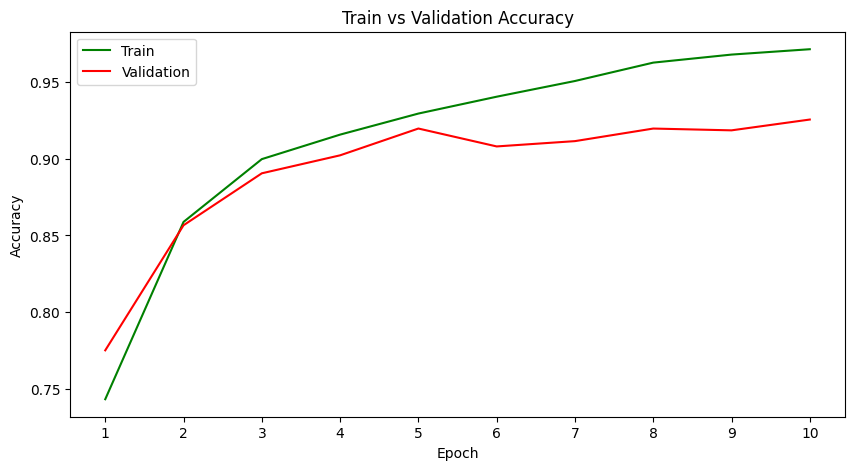

In [23]:
# Plot train vs val accuracy
plt.figure(figsize=(10, 5))
plt.plot((range(1, len(avg_train_acc) + 1)), avg_train_acc, 'g', label='Train')
plt.plot((range(1, len(avg_train_acc) + 1)), avg_val_acc, 'r', label='Validation')
plt.title('Train vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Set integer values for x-axis ticks
plt.xticks(range(1, len(avg_train_acc) + 1))

# plt.savefig('accuracy_plot.eps', format='eps', dpi=300, bbox_inches='tight')
plt.savefig('/content/drive/MyDrive/R&D/Experimental Works/FedBERT - Spam Ham/train-val acc_plot_albert-base-v2.pdf', format='pdf', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# # saving plots
# from google.colab import files
# plt.tight_layout()
# images_dir = '/content/drive/MyDrive/Team Fed/FedBert/Figure' # set path of saving location

# plt.savefig(f"{images_dir}/TrainVsVal_acc.eps") # ----saving to the path defined above
# # files.download(f"{images_dir}/image_name.") # ----download a copy to the local device

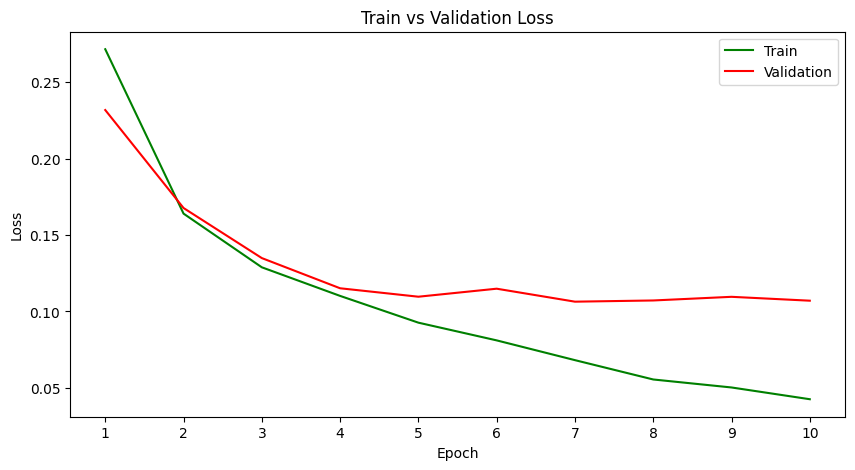

In [24]:
# Plot train vs val loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(avg_train_acc) + 1), avg_train_loss, 'g', label='Train')
plt.plot(range(1, len(avg_train_acc) + 1), avg_val_loss, 'r', label='Validation')
plt.title('Train vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Set integer values for x-axis ticks
plt.xticks(range(1, len(avg_train_acc) + 1))

# plt.savefig('accuracy_plot.eps', format='eps', dpi=300, bbox_inches='tight')
plt.savefig('/content/drive/MyDrive/R&D/Experimental Works/FedBERT - Spam Ham/train-val loss_plot_albert-base-v2.pdf', format='pdf', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# # saving plots
# from google.colab import files
# plt.tight_layout()
# images_dir = '/content/drive/MyDrive/..../' # set path of saving location

# plt.savefig(f"{images_dir}/TrainVsVal_Loss.eps") # ----saving to the path defined above
# # files.download(f"{images_dir}/image_name.") # ----download a copy to the local device

### **Test Score**

In [25]:
from sklearn.metrics import classification_report

true, predicted = server.test()
class_mapping = {
    0: 'Ham',
    1: 'Spam',
}

classification_report_str = classification_report(
    true,
    predicted,
    output_dict=False,
    target_names=class_mapping.values(),
    labels=[0, 1],
    digits=6,
)

print(classification_report_str)

              precision    recall  f1-score   support

         Ham   0.953593  0.947917  0.950746       672
        Spam   0.816754  0.834225  0.825397       187

    accuracy                       0.923166       859
   macro avg   0.885173  0.891071  0.888072       859
weighted avg   0.923804  0.923166  0.923458       859



### **Confusion Matrrix**

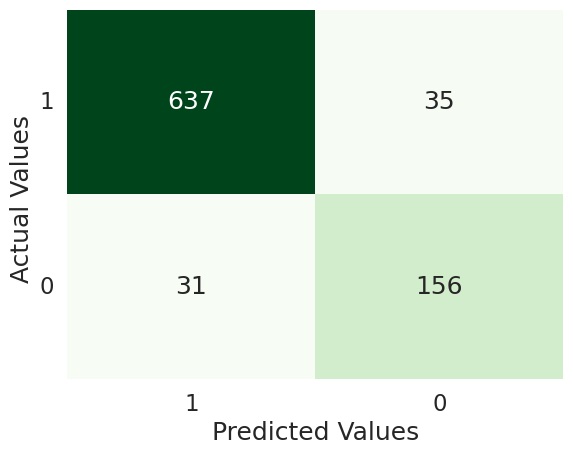

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class_names = df.label.unique()

# Compute confusion matrix
cm = confusion_matrix(true, predicted)

# Plot confusion matrix
sns.set(font_scale=1.5)
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False, xticklabels=class_names, yticklabels=class_names)

ax.set_xticklabels(class_names, rotation=0) # Rotate the x-axis tick labels
ax.set_yticklabels(class_names, rotation=0) # Rotate the y-axis tick labels
ax.set_xlabel('Predicted Values')
ax.set_ylabel('Actual Values ')

# plt.savefig('accuracy_plot.eps', format='eps', dpi=300, bbox_inches='tight')
plt.savefig('/content/drive/MyDrive/R&D/Experimental Works/FedBERT - Spam Ham/confusion_matrix_albert-base-v2.pdf', format='pdf', dpi=300, bbox_inches='tight')

plt.show()

### **Exporting Figure**

In [ ]:
# # Plot confusion matrix
# ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False)

# ax.set_xticklabels(class_names, rotation=45) # Rotate the x-axis tick labels
# ax.set_yticklabels(class_names, rotation=0) # Rotate the y-axis tick labels
# ax.set_xlabel('Predicted Values')
# ax.set_ylabel('Actual Values ')

# # saving plots
# from google.colab import files
# plt.tight_layout()
# images_dir = '/content/drive/MyDrive/....../' # set path of saving location

# plt.savefig(f"{images_dir}/cm_test_fedBert.pdf") # ----saving to the path defined above
# # files.download(f"{images_dir}/image_name.") # ----download a copy to the local device